In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import f_oneway, chi2_contingency

from toolbox_ml.eda.core import describe_df, tipifica_variables
%matplotlib inline
pd.set_option('display.max_columns', None)

df = pd.read_csv("../data_sample/data.csv", sep=';') 
df.shape

(4424, 37)

In [2]:
# PRIMER VISTAZO
df.head()

,Marital status,Application mode,Application order,Course,Daytime/evening attendance\t,Previous qualification,Previous qualification (grade),Nacionality,Mother's qualification,Father's qualification,Mother's occupation,Father's occupation,Admission grade,Displaced,Educational special needs,Debtor,Tuition fees up to date,Gender,Scholarship holder,Age at enrollment,International,Curricular units 1st sem (credited),Curricular units 1st sem (enrolled),Curricular units 1st sem (evaluations),Curricular units 1st sem (approved),Curricular units 1st sem (grade),Curricular units 1st sem (without evaluations),Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP,Target
0,1,17,5,171,1,1,122.0,1,19,12,5,9,127.3,1,0,0,1,1,0,20,0,0,0,0,0,0.000000,0,0,0,0,0,0.000000,0,10.8,1.4,1.74,Dropout
1,1,15,1,9254,1,1,160.0,1,1,3,3,3,142.5,1,0,0,0,1,0,19,0,0,6,6,6,14.000000,0,0,6,6,6,13.666667,0,13.9,-0.3,0.79,Graduate
2,1,1,5,9070,1,1,122.0,1,37,37,9,9,124.8,1,0,0,0,1,0,19,0,0,6,0,0,0.000000,0,0,6,0,0,0.000000,0,10.8,1.4,1.74,Dropout
3,1,17,2,9773,1,1,122.0,1,38,37,5,3,119.6,1,0,0,1,0,0,20,0,0,6,8,6,13.428571,0,0,6,10,5,12.400000,0,9.4,-0.8,-3.12,Graduate
4,2,39,1,8014,0,1,100.0,1,37,38,9,9,141.5,0,0,0,1,0,0,45,0,0,6,9,5,12.333333,0,0,6,6,6,13.000000,0,13.9,-0.3,0.79,Graduate


In [4]:
df.columns.tolist()

['Marital status',
 'Application mode',
 'Application order',
 'Course',
 'Daytime/evening attendance\t',
 'Previous qualification',
 'Previous qualification (grade)',
 'Nacionality',
 "Mother's qualification",
 "Father's qualification",
 "Mother's occupation",
 "Father's occupation",
 'Admission grade',
 'Displaced',
 'Educational special needs',
 'Debtor',
 'Tuition fees up to date',
 'Gender',
 'Scholarship holder',
 'Age at enrollment',
 'International',
 'Curricular units 1st sem (credited)',
 'Curricular units 1st sem (enrolled)',
 'Curricular units 1st sem (evaluations)',
 'Curricular units 1st sem (approved)',
 'Curricular units 1st sem (grade)',
 'Curricular units 1st sem (without evaluations)',
 'Curricular units 2nd sem (credited)',
 'Curricular units 2nd sem (enrolled)',
 'Curricular units 2nd sem (evaluations)',
 'Curricular units 2nd sem (approved)',
 'Curricular units 2nd sem (grade)',
 'Curricular units 2nd sem (without evaluations)',
 'Unemployment rate',
 'Inflation r

In [5]:
# LIMPIEZA DE NOMBRES
df.columns = df.columns.str.strip()
df.columns.tolist()

['Marital status',
 'Application mode',
 'Application order',
 'Course',
 'Daytime/evening attendance',
 'Previous qualification',
 'Previous qualification (grade)',
 'Nacionality',
 "Mother's qualification",
 "Father's qualification",
 "Mother's occupation",
 "Father's occupation",
 'Admission grade',
 'Displaced',
 'Educational special needs',
 'Debtor',
 'Tuition fees up to date',
 'Gender',
 'Scholarship holder',
 'Age at enrollment',
 'International',
 'Curricular units 1st sem (credited)',
 'Curricular units 1st sem (enrolled)',
 'Curricular units 1st sem (evaluations)',
 'Curricular units 1st sem (approved)',
 'Curricular units 1st sem (grade)',
 'Curricular units 1st sem (without evaluations)',
 'Curricular units 2nd sem (credited)',
 'Curricular units 2nd sem (enrolled)',
 'Curricular units 2nd sem (evaluations)',
 'Curricular units 2nd sem (approved)',
 'Curricular units 2nd sem (grade)',
 'Curricular units 2nd sem (without evaluations)',
 'Unemployment rate',
 'Inflation rat

In [6]:
target_col = 'Target'

cat_cols = [
    'Marital status', 'Application mode', 'Application order', 'Course',
    'Daytime/evening attendance', 'Previous qualification', 'Nacionality',
    "Mother's qualification", "Father's qualification",
    "Mother's occupation", "Father's occupation",
    'Displaced', 'Educational special needs', 'Debtor',
    'Tuition fees up to date', 'Gender', 'Scholarship holder', 'International'
]

num_cols = [col for col in df.columns if col not in cat_cols + [target_col]]

print("Categóricas:", len(cat_cols))
print("Numéricas:", len(num_cols))
print(num_cols)

Categóricas: 18
Numéricas: 18
['Previous qualification (grade)', 'Admission grade', 'Age at enrollment', 'Curricular units 1st sem (credited)', 'Curricular units 1st sem (enrolled)', 'Curricular units 1st sem (evaluations)', 'Curricular units 1st sem (approved)', 'Curricular units 1st sem (grade)', 'Curricular units 1st sem (without evaluations)', 'Curricular units 2nd sem (credited)', 'Curricular units 2nd sem (enrolled)', 'Curricular units 2nd sem (evaluations)', 'Curricular units 2nd sem (approved)', 'Curricular units 2nd sem (grade)', 'Curricular units 2nd sem (without evaluations)', 'Unemployment rate', 'Inflation rate', 'GDP']


In [7]:
df.columns = df.columns.str.strip()
# USANDO NUESTRO PAQUETE DE ANALISIS EDA Y ML
resumen = describe_df(df)
resumen

,tipo,porcentaje_nulos,valores_unicos,porcentaje_cardinalidad
Marital status,int64,0.0,6,0.135624
Application mode,int64,0.0,18,0.406872
Application order,int64,0.0,8,0.180832
Course,int64,0.0,17,0.384268
Daytime/evening attendance,int64,0.0,2,0.045208
Previous qualification,int64,0.0,17,0.384268
Previous qualification (grade),float64,0.0,101,2.283002
Nacionality,int64,0.0,21,0.474684
Mother's qualification,int64,0.0,29,0.655515
Father's qualification,int64,0.0,34,0.768535


### A destacar

1. **0% nulos en todas las columnas** — confirma lo que decía la ficha del dataset, no hay que imputar nada.
2. **`Target`** con 3 valores únicos — confirma el problema de clasificación multiclase (Dropout / Enrolled / Graduate).
3. **Ojo con `Unemployment rate`, `Inflation rate`, `GDP`** — son `float64` pero solo tienen 9-10 valores únicos. Esto tiene sentido: son indicadores macroeconómicos por año de matrícula, no algo que varíe por estudiante individualmente. Es decir, muchos estudiantes comparten el mismo valor porque se matricularon el mismo año. Esto es relevante de cara al análisis (no es ruido, es una variable "de cohorte").
4. **variables binarias** (`Displaced`, `Debtor`, `Gender`, `Scholarship holder`, etc. con 2 valores) — coincide con lo que ya hemos clasificado como categóricas.
5. **`Admission grade`, `Curricular units 1st/2nd sem (grade)`** tienen alta cardinalidad (14-18%), como se espera de notas continuas.

In [9]:
#  VER SI HAY UNA CLASIFICACIÓN ADECUADA

tipos = tipifica_variables(df, umbral_categorica=10, umbral_continua=70.0)
tipos

,Nombre variable,Tipo sugerido
0,Marital status,Categorica
1,Application mode,Numérica Discreta
2,Application order,Categorica
3,Course,Numérica Discreta
4,Daytime/evening attendance,Binaria
5,Previous qualification,Numérica Discreta
6,Previous qualification (grade),Numérica Discreta
7,Nacionality,Numérica Discreta
8,Mother's qualification,Numérica Discreta
9,Father's qualification,Numérica Discreta


### La clasificación automática no es fiable aquí

`tipifica_variables` solo se basa en la **cardinalidad** de cada columna (número de valores únicos frente a los umbrales definidos), sin conocer el significado real de la variable. Esto lleva a varios errores de clasificación:

1. **Categóricas nominales marcadas como "Numérica Discreta"**: `Application mode`, `Course`, `Previous qualification`, `Nacionality`, `Mother's/Father's qualification`, `Mother's/Father's occupation`. Son códigos que representan categorías (carrera, nacionalidad, ocupación...), no cantidades numéricas, aunque tengan muchos valores únicos.

2. **Variables continuas marcadas como "Numérica Discreta"**: `Admission grade` y las `Curricular units (grade)` de 1er y 2º semestre son notas continuas, no discretas.

3. **Variables continuas marcadas como "Categórica"**: `Unemployment rate`, `Inflation rate`, `GDP` y `Curricular units 2nd sem (without evaluations)`. Al tener pocos valores únicos (9-10), caen por debajo del umbral de cardinalidad y se etiquetan como categóricas, aunque conceptualmente sean indicadores numéricos continuos (de hecho, `Unemployment rate`, `Inflation rate` y `GDP` son indicadores macroeconómicos por año de matrícula, no por estudiante).

4. **`Application order`** cae en categórica por umbral, aunque conceptualmente es más bien ordinal.

**Conclusión**: para el resto del EDA usamos una clasificación manual basada en el diccionario de variables del dataset, en lugar de confiar en el resultado automático de `tipifica_variables`.

In [17]:
target_col = 'Target'

cat_cols = ['Marital status', 'Application mode', 'Application order', 'Course',
    'Daytime/evening attendance', 'Previous qualification', 'Nacionality',
    "Mother's qualification", "Father's qualification",
    "Mother's occupation", "Father's occupation",
    'Displaced', 'Educational special needs', 'Debtor',
    'Tuition fees up to date', 'Gender', 'Scholarship holder', 'International']

num_cols = ['Previous qualification (grade)', 'Admission grade', 'Age at enrollment',
    'Curricular units 1st sem (credited)', 'Curricular units 1st sem (enrolled)',
    'Curricular units 1st sem (evaluations)', 'Curricular units 1st sem (approved)',
    'Curricular units 1st sem (grade)', 'Curricular units 1st sem (without evaluations)',
    'Curricular units 2nd sem (credited)', 'Curricular units 2nd sem (enrolled)',
    'Curricular units 2nd sem (evaluations)', 'Curricular units 2nd sem (approved)',
    'Curricular units 2nd sem (grade)', 'Curricular units 2nd sem (without evaluations)',
    'Unemployment rate', 'Inflation rate', 'GDP']

# comprobación de que las listas cuadran con el total de columnas
assert len(cat_cols) + len(num_cols) + 1 == df.shape[1]
print(f"Categóricas: {len(cat_cols)} | Numéricas: {len(num_cols)} | Target: 1 | Total: {df.shape[1]}")

Categóricas: 18 | Numéricas: 18 | Target: 1 | Total: 37


In [18]:
# Distribución del target
df[target_col].value_counts()

Target
Graduate    2209
Dropout     1421
Enrolled     794
Name: count, dtype: int64

In [19]:
df[target_col].value_counts(normalize=True) * 100

Target
Graduate    49.932188
Dropout     32.120253
Enrolled    17.947559
Name: proportion, dtype: float64

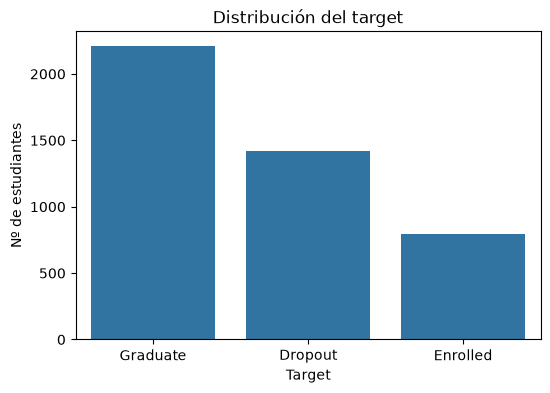

In [20]:
plt.figure(figsize=(6,4))
sns.countplot(data=df, x=target_col, order=df[target_col].value_counts().index)
plt.title("Distribución del target")
plt.ylabel("Nº de estudiantes")
plt.show()

**Observaciones:**
- Existe un desbalance moderado hacia la clase `Graduate` (~50%), seguida de `Dropout` (~32%) y `Enrolled` como clara minoritaria (~18%).
- De cara al modelado, esto implica que **accuracy no será una métrica fiable por sí sola** y convendrá usar métricas como F1-score macro o revisar la matriz de confusión por clase.
- La clase minoritaria (`Enrolled`) requerirá especial atención para evitar que el modelo la ignore en favor de las clases mayoritarias.

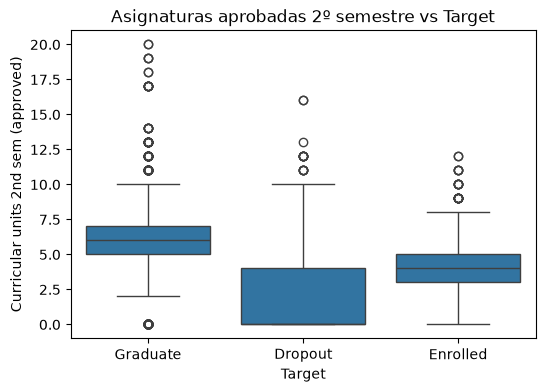

In [21]:
plt.figure(figsize=(6,4))
sns.boxplot(data=df, x=target_col, y='Curricular units 2nd sem (approved)', order=df[target_col].value_counts().index)
plt.title("Asignaturas aprobadas 2º semestre vs Target")
plt.show()

In [22]:
df.groupby(target_col)['Curricular units 2nd sem (approved)'].median()

Target
Dropout     0.0
Enrolled    4.0
Graduate    6.0
Name: Curricular units 2nd sem (approved), dtype: float64

#### Ejemplo de variable con posible fuga de datos

`Curricular units 2nd sem (approved)` — mediana por clase del target:

| Target | Mediana |
|---|---|
| Dropout | 0.0 |
| Enrolled | 4.0 |
| Graduate | 6.0 |

La separación entre clases es prácticamente total: quienes abandonan tienen mediana 0, quienes se gradúan mediana 6. Esto confirma la sospecha de que las variables `Curricular units 1st/2nd sem (...)` son consecuencia del resultado final más que un predictor independiente de él (data leakage). Se deja anotado para la fase de modelado, donde habrá que decidir si se excluyen, se usan parcialmente (solo 1er semestre) o se incluyen asumiendo esta limitación.

In [23]:
#ANOVA COMPLETO PARA LAS 18 NUMÉRICAS

resultados_num = []
for col in num_cols:
    grupos = [df[df[target_col] == cat][col] for cat in df[target_col].unique()]
    stat, pvalue = f_oneway(*grupos)
    resultados_num.append((col, stat, pvalue))

anova_df = pd.DataFrame(resultados_num, columns=['variable', 'F_stat', 'p_value'])
anova_df = anova_df.sort_values('p_value')
anova_df

,variable,F_stat,p_value
12,Curricular units 2nd sem (approved),1410.732938,0.000000e+00
13,Curricular units 2nd sem (grade),1134.109544,0.000000e+00
6,Curricular units 1st sem (approved),859.866768,3.649472e-316
7,Curricular units 1st sem (grade),713.517328,2.803052e-269
2,Age at enrollment,154.712071,1.138849e-65
11,Curricular units 2nd sem (evaluations),87.801092,4.039137e-38
10,Curricular units 2nd sem (enrolled),75.591910,5.244430e-33
4,Curricular units 1st sem (enrolled),59.467391,3.272852e-26
5,Curricular units 1st sem (evaluations),37.527840,6.897115e-17
1,Admission grade,35.648604,4.380466e-16


#### ANOVA — Variables numéricas vs Target

17 de las 18 variables numéricas muestran relación estadísticamente significativa con el target (p < 0.05). Solo `Inflation rate` no es significativa (p=0.175).

**Variables con mayor relación (posible data leakage):**
Las 4 variables con F_stat más alto son todas del bloque `Curricular units 1st/2nd sem (approved/grade)`, confirmando la sospecha de fuga de datos ya observada en el boxplot: estas variables son casi consecuencia directa del resultado académico final, no predictores independientes disponibles en el momento de matrícula.

**Variables "limpias" (disponibles en el momento de matrícula) con relación fuerte:**
- `Age at enrollment` (F=154.71) — la más destacada de este grupo
- `Admission grade` (F=35.65)
- `Previous qualification (grade)` (F=27.73)

**Variables macroeconómicas (de cohorte, por año de matrícula):**
`Unemployment rate` y `GDP` son significativas pero con relación débil (F≈5-6). `Inflation rate` no resulta significativa.

**Nota para modelado:** de cara a un modelo con utilidad práctica real (predicción temprana), convendrá evaluar excluir o tratar con cautela las variables `Curricular units` por su alto riesgo de data leakage.

In [26]:
# CHI CUADRADO CATEGÓRICAS vs TARGET

resultados_cat = []
for col in cat_cols:
    tabla = pd.crosstab(df[col], df[target_col])
    chi2, p, dof, expected = chi2_contingency(tabla)
    resultados_cat.append((col, chi2, p))

chi_df = pd.DataFrame(resultados_cat, columns=['variable', 'chi2', 'p_value'])
chi_df = chi_df.sort_values('p_value')
chi_df

,variable,chi2,p_value
14,Tuition fees up to date,823.552724,1.471628e-179
3,Course,558.284474,2.316571e-97
16,Scholarship holder,409.943055,9.593930e-90
1,Application mode,466.513683,1.964657e-77
13,Debtor,259.333220,4.858552e-57
15,Gender,233.266432,2.222480e-51
9,Mother's occupation,291.921705,1.630859e-31
5,Previous qualification,219.680709,7.160305e-30
7,Mother's qualification,217.952131,5.823844e-21
8,Father's qualification,225.000783,3.175007e-19


In [27]:
# verificar cuántos estudiantes hay por nacionalidad, porque si la mayoría son de 1-2 países y 
# el resto tiene 1-2 estudiantes cada uno, el resultado no es muy interpretable

df['Nacionality'].value_counts()

Nacionality
1      4314
41       38
26       14
6        13
22       13
24        5
103       3
11        3
100       3
62        2
25        2
21        2
101       2
2         2
105       2
13        1
32        1
109       1
108       1
14        1
17        1
Name: count, dtype: int64

#### Chi-cuadrado — Variables categóricas vs Target

15 de las 18 variables categóricas muestran relación estadísticamente significativa con el target (p < 0.05).

**Variables más relevantes (relacionadas con situación económica/administrativa):**
- `Tuition fees up to date` (chi2=823.55) — la variable categórica más relevante de todo el dataset
- `Scholarship holder` (chi2=409.94)
- `Debtor` (chi2=259.33)

Estas tres sugieren que la **situación económica del estudiante** es uno de los factores más determinantes en el abandono/graduación.

**Otras variables destacadas:**
`Course` y `Application mode` también muestran relación fuerte, indicando que ciertas carreras o vías de acceso tienen patrones de abandono/graduación muy distintos.

**Variables no significativas:**
- `Educational special needs` (p=0.725) e `International` (p=0.527): probablemente por muy pocos casos positivos en el dataset.
- `Nacionality` (p=0.242): el 97.5% de los estudiantes son de nacionalidad portuguesa (4314 de 4424), y el resto se reparte en 20 nacionalidades con muy pocos casos cada una (algunas con 1-2 estudiantes). Esto provoca frecuencias esperadas muy bajas en la tabla de contingencia, restando fiabilidad al test de Chi-cuadrado. No se puede concluir que no haya relación, solo que el test carece de potencia estadística con tan poca representación por categoría.

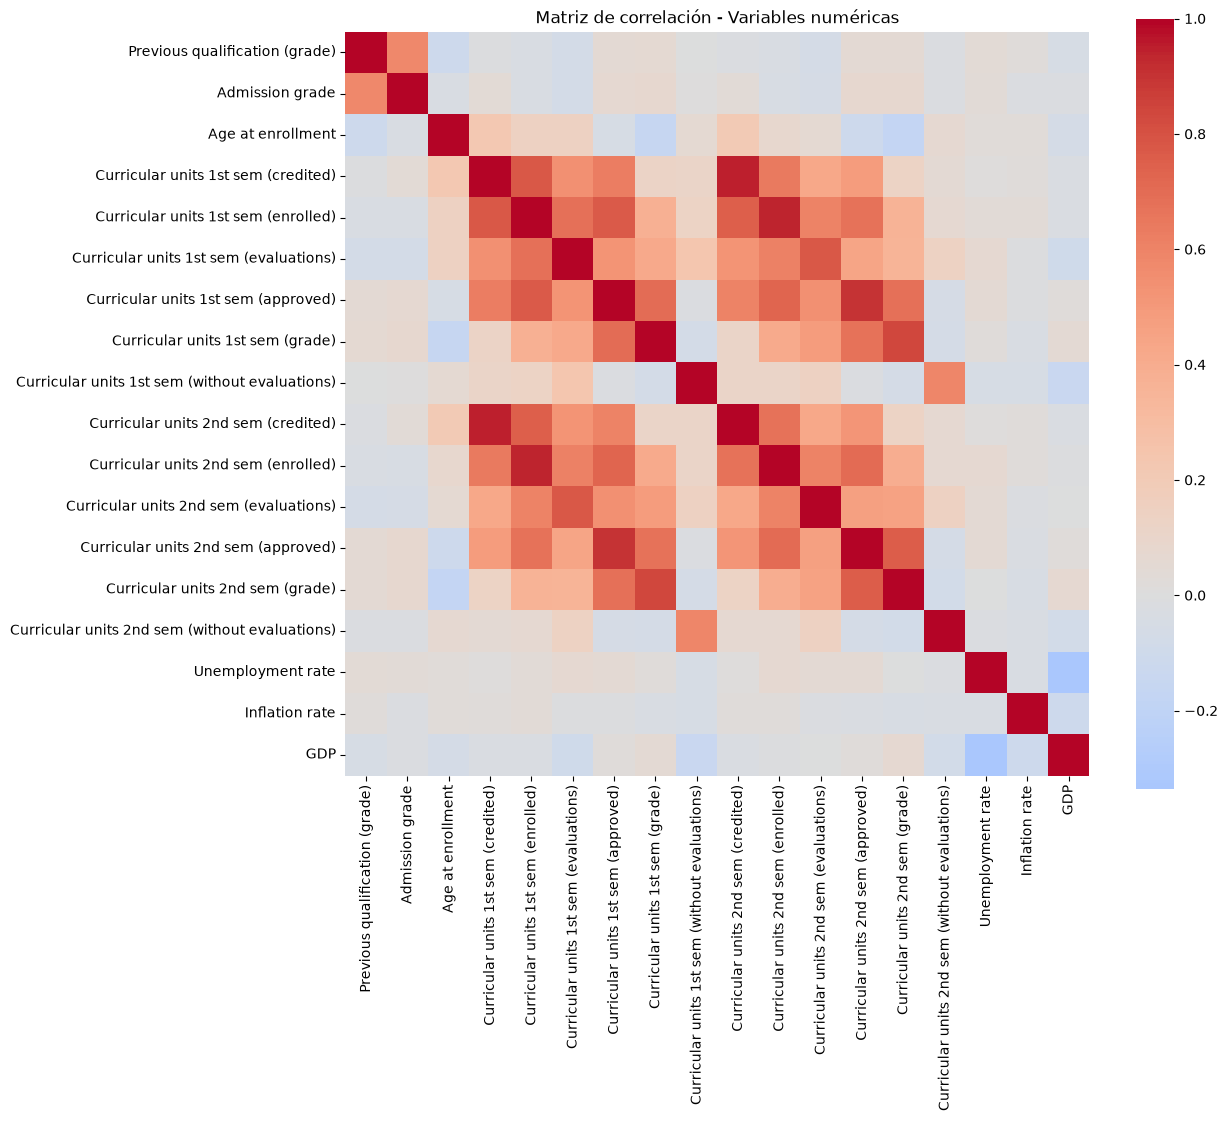

In [28]:
# MATRIZ CORRELACIÓN ENTRE NUMÉRICAS

plt.figure(figsize=(12,10))
corr_matrix = df[num_cols].corr()
sns.heatmap(corr_matrix, annot=False, cmap='coolwarm', center=0, square=True)
plt.title("Matriz de correlación - Variables numéricas")
plt.show()

In [29]:
# PARES CON CORRELACIÓN MUY ALTA (candidatos a redundancia)

# nos quedamos con pares de variables distintas y correlación absoluta alta
corr_pairs = corr_matrix.abs().unstack()
corr_pairs = corr_pairs[corr_pairs < 1.0]  # quitamos la diagonal (autocorrelación=1)
corr_pairs = corr_pairs.sort_values(ascending=False)

# eliminamos duplicados (A-B y B-A son el mismo par)
corr_pairs = corr_pairs[~corr_pairs.index.duplicated()]
top_corr = corr_pairs.drop_duplicates().head(15)
top_corr

Curricular units 2nd sem (credited)     Curricular units 1st sem (credited)       0.944811
Curricular units 2nd sem (enrolled)     Curricular units 1st sem (enrolled)       0.942627
Curricular units 2nd sem (approved)     Curricular units 1st sem (approved)       0.904002
Curricular units 1st sem (grade)        Curricular units 2nd sem (grade)          0.837170
Curricular units 2nd sem (evaluations)  Curricular units 1st sem (evaluations)    0.778863
Curricular units 1st sem (credited)     Curricular units 1st sem (enrolled)       0.774344
Curricular units 1st sem (approved)     Curricular units 1st sem (enrolled)       0.769083
Curricular units 2nd sem (approved)     Curricular units 2nd sem (grade)          0.760804
Curricular units 1st sem (enrolled)     Curricular units 2nd sem (credited)       0.753747
Curricular units 1st sem (approved)     Curricular units 2nd sem (enrolled)       0.733772
Curricular units 2nd sem (enrolled)     Curricular units 2nd sem (approved)       0.703258

#### Conclusiones generales del mini EDA

##### 1. Estructura del dataset
- **4424 estudiantes, 37 columnas** (36 features + 1 target), sin valores nulos.
- **18 variables categóricas** y **18 numéricas**, según clasificación manual basada en el diccionario de variables (la función automática `tipifica_variables` clasificó mal varias columnas por depender solo de cardinalidad, no de significado semántico).

##### 2. Target: clasificación multiclase con desbalance moderado
| Clase | Nº estudiantes | % |
|---|---|---|
| Graduate | 2209 | 49.9% |
| Dropout | 1421 | 32.1% |
| Enrolled | 794 | 17.9% |

De cara al modelado: evitar depender solo de accuracy, priorizar métricas como F1 macro y vigilar el rendimiento sobre `Enrolled` (clase minoritaria).

##### 3. Alerta importante: posible fuga de datos (data leakage)
Las variables `Curricular units 1st/2nd sem (approved, grade, enrolled, evaluations...)` muestran una relación extremadamente fuerte con el target (F_stat de hasta 1410 en ANOVA), y un ejemplo concreto lo confirma: la mediana de asignaturas aprobadas en 2º semestre es **0 para Dropout** y **6 para Graduate**. 

Estas variables son casi consecuencia directa del resultado final, no predictores independientes disponibles en el momento de la matrícula. **Habrá que decidir en la fase de modelado** si se excluyen, se usan parcialmente (solo 1er semestre, para un modelo de alerta a mitad de curso) o se incluyen asumiendo esta limitación.

##### 4. Variables numéricas "limpias" con relación real (disponibles en matrícula)
- `Age at enrollment` (F=154.71) — la más destacada de este grupo
- `Admission grade` (F=35.65)
- `Previous qualification (grade)` (F=27.73)

Estas son las candidatas más sólidas para un modelo de predicción temprana sin leakage.

##### 5. Variables categóricas más relevantes
Los factores económicos/administrativos destacan con claridad:
- `Tuition fees up to date` (chi2=823.55) — la variable categórica más relevante del dataset
- `Scholarship holder` (chi2=409.94)
- `Debtor` (chi2=259.33)

También `Course` y `Application mode` muestran relación fuerte, sugiriendo diferencias notables de abandono/graduación según carrera y vía de acceso.

##### 6. Variables sin relación significativa (o con test poco fiable)
- `Inflation rate` (numérica, p=0.175)
- `Educational special needs` e `International` (categóricas, muy pocos casos positivos)
- `Nacionality` (categórica, p=0.242 — pero el 97.5% de estudiantes son de una sola nacionalidad, lo que invalida la fiabilidad del test; se recomienda recodificar como binaria Portuguesa/Extranjera si se quiere aprovechar)

##### 7. Variables macroeconómicas (de cohorte)
`Unemployment rate` y `GDP` muestran relación significativa pero débil (F≈5-6), coherente con ser indicadores compartidos por año de matrícula más que características individuales del estudiante.

##### 8. Multicolinealidad entre variables numéricas

- Las variables del bloque `Curricular units` presentan correlaciones muy altas entre sí, tanto entre semestres (ej. `credited` 1er vs 2º sem: r=0.94; `enrolled` 1er vs 2º sem: r=0.94; `approved` 1er vs 2º sem: r=0.90) como dentro del mismo semestre (ej. `enrolled` vs `approved`, `enrolled` vs `evaluations`, r≈0.68-0.77).

- Esto confirma que estas variables son en gran parte redundantes entre sí, además del problema de data leakage ya detectado. **Recomendación para modelado:** de decidirse usar estas variables, valorar seleccionar un subconjunto representativo (por ejemplo, solo `approved` de cada semestre) en lugar de las 12 variables completas, para reducir colinealidad y simplificar el modelo.
---

##### Próximos pasos sugeridos (fuera del alcance de este mini EDA)
- Decidir tratamiento de las variables `Curricular units` (leakage) antes de modelar
- Evaluar recodificación de `Nacionality`
- Considerar matriz de correlación entre numéricas para detectar multicolinealidad
- Definir estrategia de balanceo de clases (class_weight, SMOTE, etc.) y métricas de evaluación (F1 macro, matriz de confusión)

